In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import GroupKFold, cross_val_score, train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

In [2]:
df = pd.read_csv('Merged_SoilMoisture_Data.csv')

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Points: {df['Point_ID'].nunique()}  |  Dates: {df['Date'].nunique()}")

Loaded: 401 rows × 17 columns
Points: 100  |  Dates: 22


In [4]:
def engineer_features(df):
    df = df.copy()
 
    #  Temporal features (captures seasonal SM cycle) 
    df['month']     = df['Date'].dt.month
    df['doy']       = df['Date'].dt.dayofyear
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
 
    #  Fix 3 missing SAR values (spatial median per point) 
    for col in ['VV_500m', 'VH_500m', 'Angle_500m']:
        null_mask = df[col].isnull()
        if null_mask.sum() > 0:
            fill = df.groupby('Point_ID')[col].transform('median')
            df.loc[null_mask, col] = fill[null_mask]
 
    #  SAR physics features 
    df['VV_linear']  = 10 ** (df['VV_500m'] / 10)   # dB → linear
    df['VH_linear']  = 10 ** (df['VH_500m'] / 10)
    df['VV_VH_diff'] = df['VV_500m'] - df['VH_500m']
 
    #  Terrain interaction features 
    df['slope_elev']  = df['Elevation_m'] / (df['Slope'] + 0.1)
    df['rough_slope'] = df['Roughness'] * df['Slope']
 
    df['VV_x_season'] = df['VV_linear'] * df['month_sin']
    df['VH_x_season'] = df['VH_linear'] * df['month_sin']
    df['VV_x_cos']    = df['VV_linear'] * df['month_cos']
    df['VH_x_cos']    = df['VH_linear'] * df['month_cos']
    df['sin_doy'] = np.sin(2*np.pi*df['doy']/365)
    df['cos_doy'] = np.cos(2*np.pi*df['doy']/365)
    # Dual polarization power
    df['total_power'] = df['VV_linear'] + df['VH_linear']

    # Polarization entropy proxy
    df['pol_entropy'] = -( (df['VV_linear']/(df['VV_linear']+df['VH_linear'])) * 
                        np.log(df['VV_linear']/(df['VV_linear']+df['VH_linear'])) )
    df['northness']      = np.cos(np.radians(df['Aspect']))
    df['eastness']       = np.sin(np.radians(df['Aspect']))
 
    return df
 
df = engineer_features(df)
 

In [5]:
import numpy as np
import pandas as pd
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# ─────────────────────────────────────────────
#  FEATURES
# ─────────────────────────────────────────────

FEATURES = [
    'VV_500m', 'VH_500m', 'Angle_500m',
    'VV_linear', 'VH_linear', 'VV_VH_diff',
    'CR=VH/VV', 'RVI', 'NDPI=(VV-VH)/(VV+VH)', 'MPI',
    'Elevation_m', 'Slope', 'Roughness',
    'slope_elev', 'rough_slope',
    'VV_x_season', 'VH_x_season', 'VV_x_cos', 'VH_x_cos',
    'sin_doy', 'cos_doy', 'pol_entropy', 'northness', 'eastness'
]

X = df[FEATURES].copy()
y = df['Observed_SM'].copy()


# ─────────────────────────────────────────────
#  3-WAY SPATIAL SPLIT  (Train / Val / Test)
# ─────────────────────────────────────────────

all_points = df['Point_ID'].unique()
np.random.seed(42)
shuffled = np.random.permutation(all_points)

test_pts  = shuffled[:20]       # ~20% — final holdout, touched only at the end
val_pts   = shuffled[20:35]     # ~15% — monitor overfitting, tune weights
train_pts = shuffled[35:]       # ~65% — Optuna CV + model fitting

train_mask = df['Point_ID'].isin(train_pts)
val_mask   = df['Point_ID'].isin(val_pts)
test_mask  = df['Point_ID'].isin(test_pts)

X_train_df   = X[train_mask].reset_index(drop=True)
y_train_s    = y[train_mask].reset_index(drop=True)
groups_train = df.loc[train_mask, 'Point_ID'].reset_index(drop=True).values

X_val_df     = X[val_mask].reset_index(drop=True)
y_val_s      = y[val_mask].reset_index(drop=True)

X_test_df    = X[test_mask].reset_index(drop=True)
y_test_s     = y[test_mask].reset_index(drop=True)

# Scaler fit on train only
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train_df)
X_val_sc   = scaler.transform(X_val_df)
X_test_sc  = scaler.transform(X_test_df)

y_train = y_train_s.values
y_val   = y_val_s.values
y_test  = y_test_s.values

gkf = GroupKFold(n_splits=5)

print(f"Split summary:")
print(f"  Train : {len(train_pts)} points, {train_mask.sum()} rows")
print(f"  Val   : {len(val_pts)} points, {val_mask.sum()} rows")
print(f"  Test  : {len(test_pts)} points, {test_mask.sum()} rows")


# ─────────────────────────────────────────────
#  METRICS
# ─────────────────────────────────────────────

def full_metrics(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    r    = np.corrcoef(y_true, y_pred)[0, 1]
    print(f"\n{'─'*40}")
    print(f"  {label}")
    print(f"{'─'*40}")
    print(f"  R²   : {r2:.4f}")
    print(f"  R    : {r:.4f}")
    print(f"  RMSE : {rmse:.4f} m³/m³")
    print(f"  MAE  : {mae:.4f} m³/m³")
    print(f"  Bias : {bias:.4f} m³/m³")
    return dict(r2=r2, r=r, rmse=rmse, mae=mae, bias=bias)


# ─────────────────────────────────────────────
#  OPTUNA — XGBoost
# ─────────────────────────────────────────────

print("\nTuning XGBoost with Optuna...")

def xgb_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 200, 1000),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        learning_rate    = trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        subsample        = trial.suggest_float('subsample', 0.3, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        gamma            = trial.suggest_float('gamma', 0.0, 2.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 5.0),
        reg_lambda       = trial.suggest_float('reg_lambda', 0.5, 10.0),
        objective        = 'reg:squarederror',
        tree_method      = 'hist',
        random_state     = 42,
        n_jobs           = -1,
    )

    fold_scores = []
    for tr_idx, val_idx in gkf.split(X_train_df, y_train_s, groups_train):
        X_tr  = X_train_df.iloc[tr_idx].values
        X_v   = X_train_df.iloc[val_idx].values
        y_tr  = y_train_s.iloc[tr_idx].values
        y_v   = y_train_s.iloc[val_idx].values

        sc      = RobustScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_v_sc  = sc.transform(X_v)

        model = XGBRegressor(**params)
        model.fit(X_tr_sc, y_tr, verbose=False)
        fold_scores.append(r2_score(y_v, model.predict(X_v_sc)))

    return np.mean(fold_scores)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f"\nXGB best CV R² : {study.best_value:.4f}")
print(f"XGB best params: {study.best_params}")


# ─────────────────────────────────────────────
#  OPTUNA — ExtraTrees
# ─────────────────────────────────────────────

print("\nTuning ExtraTrees with Optuna...")

def et_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 15),
        max_features     = trial.suggest_float('max_features', 0.3, 1.0),
    )

    fold_scores = []
    for tr_idx, val_idx in gkf.split(X_train_df, y_train_s, groups_train):
        X_tr  = X_train_df.iloc[tr_idx].values
        X_v   = X_train_df.iloc[val_idx].values
        y_tr  = y_train_s.iloc[tr_idx].values
        y_v   = y_train_s.iloc[val_idx].values

        sc      = RobustScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_v_sc  = sc.transform(X_v)

        model = ExtraTreesRegressor(**params, random_state=42, n_jobs=-1)
        model.fit(X_tr_sc, y_tr)
        fold_scores.append(r2_score(y_v, model.predict(X_v_sc)))

    return np.mean(fold_scores)

study_et = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_et.optimize(et_objective, n_trials=100, show_progress_bar=True)

print(f"\nET  best CV R² : {study_et.best_value:.4f}")
print(f"ET  best params: {study_et.best_params}")


# ─────────────────────────────────────────────
#  TRAIN FINAL MODELS
# ─────────────────────────────────────────────

best_xgb_params = study.best_params.copy()
best_xgb_params.update(dict(
    objective    = 'reg:squarederror',
    tree_method  = 'hist',
    random_state = 42,
    n_jobs       = -1,
))

best_xgb = XGBRegressor(**best_xgb_params)
best_et  = ExtraTreesRegressor(**study_et.best_params, random_state=42, n_jobs=-1)

# XGBoost: pass val set as eval_set to monitor validation RMSE during training
best_xgb.fit(
    X_train_sc, y_train,
    eval_set=[(X_train_sc, y_train), (X_val_sc, y_val)],
    verbose=False        # change to 50 to print val-RMSE every 50 rounds
)

best_et.fit(X_train_sc, y_train)


# ─────────────────────────────────────────────
#  TUNE ENSEMBLE WEIGHTS  (on spatial val set)
# ─────────────────────────────────────────────

xgb_val_pred = best_xgb.predict(X_val_sc)
et_val_pred  = best_et.predict(X_val_sc)

best_r2, best_w = -999, 0.5
for w in np.arange(0.1, 0.95, 0.05):
    r2 = r2_score(y_val, w * xgb_val_pred + (1 - w) * et_val_pred)
    if r2 > best_r2:
        best_r2, best_w = r2, w

wx = round(best_w, 2)
we = round(1 - wx, 2)
print(f"\nBest ensemble weights — XGB: {wx}  ET: {we}")
print(f"Val  R² with best weights : {best_r2:.4f}")


# ─────────────────────────────────────────────
#  EVALUATE  (Train / Val / Test)
# ─────────────────────────────────────────────

train_pred = wx * best_xgb.predict(X_train_sc) + we * best_et.predict(X_train_sc)
val_pred   = wx * xgb_val_pred                 + we * et_val_pred
test_pred  = wx * best_xgb.predict(X_test_sc)  + we * best_et.predict(X_test_sc)

train_m = full_metrics(y_train, train_pred, "TRAIN")
val_m   = full_metrics(y_val,   val_pred,   "VALIDATION (spatial holdout)")
test_m  = full_metrics(y_test,  test_pred,  "TEST (spatial holdout)")


# ─────────────────────────────────────────────
#  5-FOLD SPATIAL CV  (training data only)
# ─────────────────────────────────────────────

print(f"\n{'─'*40}")
print(f"  5-FOLD SPATIAL CV (train split only)")
print(f"{'─'*40}")

fold_r2, fold_rmse, fold_mae = [], [], []

for fold, (tr_idx, v_idx) in enumerate(
        gkf.split(X_train_df, y_train_s, groups=groups_train), 1):

    X_tr  = X_train_df.iloc[tr_idx].values
    X_v   = X_train_df.iloc[v_idx].values
    y_tr  = y_train[tr_idx]
    y_v   = y_train[v_idx]

    sc      = RobustScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_v_sc  = sc.transform(X_v)

    m_xgb = XGBRegressor(**best_xgb_params)
    m_et  = ExtraTreesRegressor(**study_et.best_params, random_state=42, n_jobs=-1)

    m_xgb.fit(X_tr_sc, y_tr, verbose=False)
    m_et.fit(X_tr_sc, y_tr)

    v_pred = wx * m_xgb.predict(X_v_sc) + we * m_et.predict(X_v_sc)

    f_r2   = r2_score(y_v, v_pred)
    f_rmse = np.sqrt(mean_squared_error(y_v, v_pred))
    f_mae  = mean_absolute_error(y_v, v_pred)

    fold_r2.append(f_r2);  fold_rmse.append(f_rmse);  fold_mae.append(f_mae)

    print(f"  Fold {fold}  →  R²={f_r2:.4f}  RMSE={f_rmse:.4f}  MAE={f_mae:.4f}")

print(f"{'─'*40}")
print(f"  Mean  →  R²={np.mean(fold_r2):.4f}  RMSE={np.mean(fold_rmse):.4f}  MAE={np.mean(fold_mae):.4f}")
print(f"  Std   →  R²={np.std(fold_r2):.4f}  RMSE={np.std(fold_rmse):.4f}  MAE={np.std(fold_mae):.4f}")


# ─────────────────────────────────────────────
#  FEATURE IMPORTANCE
# ─────────────────────────────────────────────

xgb_imp = pd.Series(best_xgb.feature_importances_, index=imp_shapfeatures)
et_imp  = pd.Series(best_et.feature_importances_,  index=imp_shapfeatures)
avg_imp = (wx * xgb_imp + we * et_imp).sort_values(ascending=False)

print("\nTop 10 Feature Importances (weighted avg):")
print(avg_imp.head(10).round(4).to_string())

Split summary:
  Train : 65 points, 264 rows
  Val   : 15 points, 59 rows
  Test  : 20 points, 78 rows

Tuning XGBoost with Optuna...


  0%|          | 0/100 [00:00<?, ?it/s]


XGB best CV R² : -0.0383
XGB best params: {'n_estimators': 805, 'max_depth': 8, 'learning_rate': 0.033529971162014754, 'subsample': 0.5859626963866816, 'colsample_bytree': 0.7503739727842984, 'min_child_weight': 3, 'gamma': 1.169841871013195, 'reg_alpha': 0.07755190997113592, 'reg_lambda': 6.861430559642949}

Tuning ExtraTrees with Optuna...


  0%|          | 0/100 [00:00<?, ?it/s]


ET  best CV R² : 0.1897
ET  best params: {'n_estimators': 114, 'max_depth': 8, 'min_samples_leaf': 7, 'max_features': 0.8365705263315676}

Best ensemble weights — XGB: 0.1  ET: 0.9
Val  R² with best weights : 0.4591

────────────────────────────────────────
  TRAIN
────────────────────────────────────────
  R²   : 0.5577
  R    : 0.8007
  RMSE : 0.0532 m³/m³
  MAE  : 0.0431 m³/m³
  Bias : 0.0000 m³/m³

────────────────────────────────────────
  VALIDATION (spatial holdout)
────────────────────────────────────────
  R²   : 0.4591
  R    : 0.7447
  RMSE : 0.0622 m³/m³
  MAE  : 0.0478 m³/m³
  Bias : 0.0039 m³/m³

────────────────────────────────────────
  TEST (spatial holdout)
────────────────────────────────────────
  R²   : 0.3856
  R    : 0.6690
  RMSE : 0.0666 m³/m³
  MAE  : 0.0522 m³/m³
  Bias : -0.0003 m³/m³

────────────────────────────────────────
  5-FOLD SPATIAL CV (train split only)
────────────────────────────────────────
  Fold 1  →  R²=0.3108  RMSE=0.0690  MAE=0.0590
  Fol

NameError: name 'imp_shapfeatures' is not defined

Computing SHAP for XGBoost...
Computing SHAP for ExtraTrees...


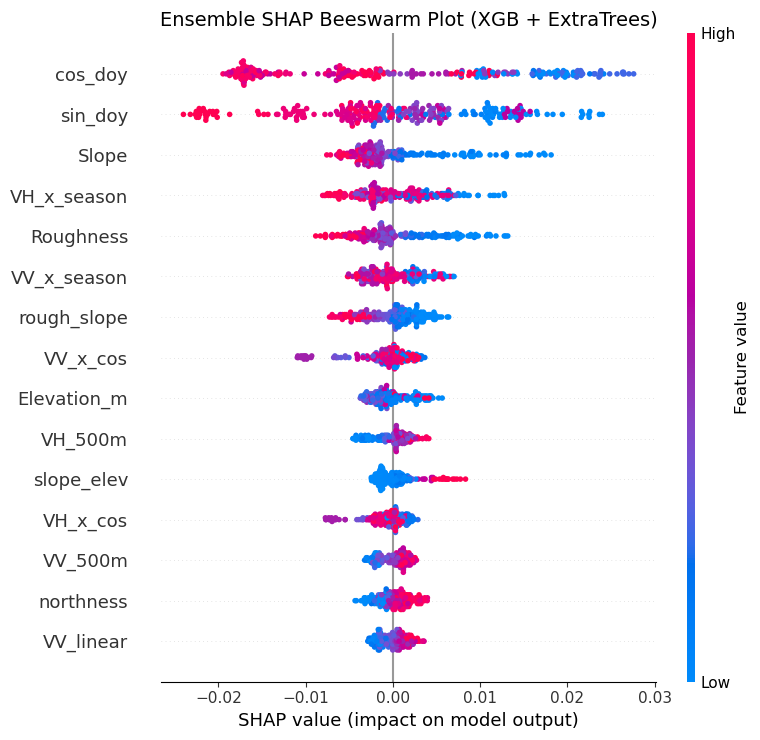

In [6]:
import shap
import numpy as np
import matplotlib.pyplot as plt


# STEP 1 — SHAP FOR XGBOOST

print("Computing SHAP for XGBoost...")

explainer_xgb = shap.TreeExplainer(best_xgb)
shap_xgb = explainer_xgb.shap_values(X_train_sc)


# STEP 2 — SHAP FOR EXTRA TREES
print("Computing SHAP for ExtraTrees...")

explainer_et = shap.TreeExplainer(best_et)
shap_et = explainer_et.shap_values(X_train_sc)


# STEP 3 — ENSEMBLE SHAP (WEIGHTED)

ensemble_shap = (
    wx * shap_xgb +
    we * shap_et
)

# Convert to mean absolute importance
shap_importance = np.abs(ensemble_shap).mean(axis=0)

# Create ranked series
shap_importance = shap_importance / shap_importance.sum()


# STEP 4 — PROFESSIONAL PLOT (CLEAN BARH)

import pandas as pd

imp_series = pd.Series(shap_importance, index=FEATURES)
imp_series = imp_series.sort_values(ascending=True)

plt.figure(figsize=(10, 7))

shap.summary_plot(
    ensemble_shap,
    X_train_sc,
    feature_names=FEATURES,
    max_display=15,
    show=False
)

plt.title("Ensemble SHAP Beeswarm Plot (XGB + ExtraTrees)", fontsize=14)

plt.tight_layout()
plt.show()

In [7]:
imp_shapfeatures= imp_series.sort_values(ascending=False).head(12).index.tolist()

In [8]:
imp_shapfeatures

['cos_doy',
 'sin_doy',
 'Slope',
 'VH_x_season',
 'Roughness',
 'VV_x_season',
 'rough_slope',
 'VV_x_cos',
 'Elevation_m',
 'VH_500m',
 'slope_elev',
 'VH_x_cos']

In [9]:
import numpy as np
import pandas as pd
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# ─────────────────────────────────────────────
#  FEATURES
# ─────────────────────────────────────────────

FEATURES = [
    'VV_500m', 'VH_500m', 'Angle_500m',
    'VV_linear', 'VH_linear', 'VV_VH_diff',
    'CR=VH/VV', 'RVI', 'NDPI=(VV-VH)/(VV+VH)', 'MPI',
    'Elevation_m', 'Slope', 'Roughness',
    'slope_elev', 'rough_slope',
    'VV_x_season', 'VH_x_season', 'VV_x_cos', 'VH_x_cos',
    'sin_doy', 'cos_doy', 'pol_entropy', 'northness', 'eastness'
]

X = df[imp_shapfeatures].copy()
y = df['Observed_SM'].copy()


# ─────────────────────────────────────────────
#  3-WAY SPATIAL SPLIT  (Train / Val / Test)
# ─────────────────────────────────────────────

all_points = df['Point_ID'].unique()
np.random.seed(42)
shuffled = np.random.permutation(all_points)

test_pts  = shuffled[:20]       # ~20% — final holdout, touched only at the end
val_pts   = shuffled[20:30]     # ~15% — monitor overfitting, tune weights
train_pts = shuffled[30:]       # ~65% — Optuna CV + model fitting

train_mask = df['Point_ID'].isin(train_pts)
val_mask   = df['Point_ID'].isin(val_pts)
test_mask  = df['Point_ID'].isin(test_pts)

X_train_df   = X[train_mask].reset_index(drop=True)
y_train_s    = y[train_mask].reset_index(drop=True)
groups_train = df.loc[train_mask, 'Point_ID'].reset_index(drop=True).values

X_val_df     = X[val_mask].reset_index(drop=True)
y_val_s      = y[val_mask].reset_index(drop=True)

X_test_df    = X[test_mask].reset_index(drop=True)
y_test_s     = y[test_mask].reset_index(drop=True)

# Scaler fit on train only
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train_df)
X_val_sc   = scaler.transform(X_val_df)
X_test_sc  = scaler.transform(X_test_df)

y_train = y_train_s.values
y_val   = y_val_s.values
y_test  = y_test_s.values

gkf = GroupKFold(n_splits=5)

print(f"Split summary:")
print(f"  Train : {len(train_pts)} points, {train_mask.sum()} rows")
print(f"  Val   : {len(val_pts)} points, {val_mask.sum()} rows")
print(f"  Test  : {len(test_pts)} points, {test_mask.sum()} rows")


# ─────────────────────────────────────────────
#  METRICS
# ─────────────────────────────────────────────

def full_metrics(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    r    = np.corrcoef(y_true, y_pred)[0, 1]
    print(f"\n{'─'*40}")
    print(f"  {label}")
    print(f"{'─'*40}")
    print(f"  R²   : {r2:.4f}")
    print(f"  R    : {r:.4f}")
    print(f"  RMSE : {rmse:.4f} m³/m³")
    print(f"  MAE  : {mae:.4f} m³/m³")
    print(f"  Bias : {bias:.4f} m³/m³")
    return dict(r2=r2, r=r, rmse=rmse, mae=mae, bias=bias)


# ─────────────────────────────────────────────
#  OPTUNA — XGBoost
# ─────────────────────────────────────────────

print("\nTuning XGBoost with Optuna...")

def xgb_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 200, 1000),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        learning_rate    = trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        subsample        = trial.suggest_float('subsample', 0.3, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        gamma            = trial.suggest_float('gamma', 0.0, 2.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 5.0),
        reg_lambda       = trial.suggest_float('reg_lambda', 0.5, 10.0),
        objective        = 'reg:squarederror',
        tree_method      = 'hist',
        random_state     = 42,
        n_jobs           = -1,
    )

    fold_scores = []
    for tr_idx, val_idx in gkf.split(X_train_df, y_train_s, groups_train):
        X_tr  = X_train_df.iloc[tr_idx].values
        X_v   = X_train_df.iloc[val_idx].values
        y_tr  = y_train_s.iloc[tr_idx].values
        y_v   = y_train_s.iloc[val_idx].values

        sc      = RobustScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_v_sc  = sc.transform(X_v)

        model = XGBRegressor(**params)
        model.fit(X_tr_sc, y_tr, verbose=False)
        fold_scores.append(r2_score(y_v, model.predict(X_v_sc)))

    return np.mean(fold_scores)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f"\nXGB best CV R² : {study.best_value:.4f}")
print(f"XGB best params: {study.best_params}")


# ─────────────────────────────────────────────
#  OPTUNA — ExtraTrees
# ─────────────────────────────────────────────

print("\nTuning ExtraTrees with Optuna...")

def et_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 15),
        max_features     = trial.suggest_float('max_features', 0.3, 1.0),
    )

    fold_scores = []
    for tr_idx, val_idx in gkf.split(X_train_df, y_train_s, groups_train):
        X_tr  = X_train_df.iloc[tr_idx].values
        X_v   = X_train_df.iloc[val_idx].values
        y_tr  = y_train_s.iloc[tr_idx].values
        y_v   = y_train_s.iloc[val_idx].values

        sc      = RobustScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_v_sc  = sc.transform(X_v)

        model = ExtraTreesRegressor(**params, random_state=42, n_jobs=-1)
        model.fit(X_tr_sc, y_tr)
        fold_scores.append(r2_score(y_v, model.predict(X_v_sc)))

    return np.mean(fold_scores)

study_et = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_et.optimize(et_objective, n_trials=100, show_progress_bar=True)

print(f"\nET  best CV R² : {study_et.best_value:.4f}")
print(f"ET  best params: {study_et.best_params}")


# ─────────────────────────────────────────────
#  TRAIN FINAL MODELS
# ─────────────────────────────────────────────

best_xgb_params = study.best_params.copy()
best_xgb_params.update(dict(
    objective    = 'reg:squarederror',
    tree_method  = 'hist',
    random_state = 42,
    n_jobs       = -1,
))

best_xgb = XGBRegressor(**best_xgb_params)
best_et  = ExtraTreesRegressor(**study_et.best_params, random_state=42, n_jobs=-1)

# XGBoost: pass val set as eval_set to monitor validation RMSE during training
best_xgb.fit(
    X_train_sc, y_train,
    eval_set=[(X_train_sc, y_train), (X_val_sc, y_val)],
    verbose=False        # change to 50 to print val-RMSE every 50 rounds
)

best_et.fit(X_train_sc, y_train)


# ─────────────────────────────────────────────
#  TUNE ENSEMBLE WEIGHTS  (on spatial val set)
# ─────────────────────────────────────────────

xgb_val_pred = best_xgb.predict(X_val_sc)
et_val_pred  = best_et.predict(X_val_sc)

best_r2, best_w = -999, 0.5
for w in np.arange(0.1, 0.95, 0.05):
    r2 = r2_score(y_val, w * xgb_val_pred + (1 - w) * et_val_pred)
    if r2 > best_r2:
        best_r2, best_w = r2, w

wx = round(best_w, 2)
we = round(1 - wx, 2)
print(f"\nBest ensemble weights — XGB: {wx}  ET: {we}")
print(f"Val  R² with best weights : {best_r2:.4f}")


# ─────────────────────────────────────────────
#  EVALUATE  (Train / Val / Test)
# ─────────────────────────────────────────────

train_pred = wx * best_xgb.predict(X_train_sc) + we * best_et.predict(X_train_sc)
val_pred   = wx * xgb_val_pred                 + we * et_val_pred
test_pred  = wx * best_xgb.predict(X_test_sc)  + we * best_et.predict(X_test_sc)

train_m = full_metrics(y_train, train_pred, "TRAIN")
val_m   = full_metrics(y_val,   val_pred,   "VALIDATION (spatial holdout)")
test_m  = full_metrics(y_test,  test_pred,  "TEST (spatial holdout)")


# ─────────────────────────────────────────────
#  5-FOLD SPATIAL CV  (training data only)
# ─────────────────────────────────────────────

print(f"\n{'─'*40}")
print(f"  5-FOLD SPATIAL CV (train split only)")
print(f"{'─'*40}")

fold_r2, fold_rmse, fold_mae = [], [], []

for fold, (tr_idx, v_idx) in enumerate(
        gkf.split(X_train_df, y_train_s, groups=groups_train), 1):

    X_tr  = X_train_df.iloc[tr_idx].values
    X_v   = X_train_df.iloc[v_idx].values
    y_tr  = y_train[tr_idx]
    y_v   = y_train[v_idx]

    sc      = RobustScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_v_sc  = sc.transform(X_v)

    m_xgb = XGBRegressor(**best_xgb_params)
    m_et  = ExtraTreesRegressor(**study_et.best_params, random_state=42, n_jobs=-1)

    m_xgb.fit(X_tr_sc, y_tr, verbose=False)
    m_et.fit(X_tr_sc, y_tr)

    v_pred = wx * m_xgb.predict(X_v_sc) + we * m_et.predict(X_v_sc)

    f_r2   = r2_score(y_v, v_pred)
    f_rmse = np.sqrt(mean_squared_error(y_v, v_pred))
    f_mae  = mean_absolute_error(y_v, v_pred)

    fold_r2.append(f_r2);  fold_rmse.append(f_rmse);  fold_mae.append(f_mae)

    print(f"  Fold {fold}  →  R²={f_r2:.4f}  RMSE={f_rmse:.4f}  MAE={f_mae:.4f}")

print(f"{'─'*40}")
print(f"  Mean  →  R²={np.mean(fold_r2):.4f}  RMSE={np.mean(fold_rmse):.4f}  MAE={np.mean(fold_mae):.4f}")
print(f"  Std   →  R²={np.std(fold_r2):.4f}  RMSE={np.std(fold_rmse):.4f}  MAE={np.std(fold_mae):.4f}")


# ─────────────────────────────────────────────
#  FEATURE IMPORTANCE
# ─────────────────────────────────────────────

xgb_imp = pd.Series(best_xgb.feature_importances_, index=imp_shapfeatures)
et_imp  = pd.Series(best_et.feature_importances_,  index=imp_shapfeatures)
avg_imp = (wx * xgb_imp + we * et_imp).sort_values(ascending=False)

print("\nTop 10 Feature Importances (weighted avg):")
print(avg_imp.head(10).round(4).to_string())

Split summary:
  Train : 70 points, 285 rows
  Val   : 10 points, 38 rows
  Test  : 20 points, 78 rows

Tuning XGBoost with Optuna...


  0%|          | 0/100 [00:00<?, ?it/s]


XGB best CV R² : 0.3041
XGB best params: {'n_estimators': 851, 'max_depth': 5, 'learning_rate': 0.022946364928538163, 'subsample': 0.8908239341939264, 'colsample_bytree': 0.8944158291782791, 'min_child_weight': 9, 'gamma': 0.004501415398059744, 'reg_alpha': 0.14480473803355545, 'reg_lambda': 4.72742262533354}

Tuning ExtraTrees with Optuna...


  0%|          | 0/100 [00:00<?, ?it/s]


ET  best CV R² : 0.3544
ET  best params: {'n_estimators': 114, 'max_depth': 10, 'min_samples_leaf': 4, 'max_features': 0.9515626883739587}

Best ensemble weights — XGB: 0.1  ET: 0.9
Val  R² with best weights : 0.5699

────────────────────────────────────────
  TRAIN
────────────────────────────────────────
  R²   : 0.7002
  R    : 0.8569
  RMSE : 0.0442 m³/m³
  MAE  : 0.0352 m³/m³
  Bias : 0.0000 m³/m³

────────────────────────────────────────
  VALIDATION (spatial holdout)
────────────────────────────────────────
  R²   : 0.5699
  R    : 0.7741
  RMSE : 0.0536 m³/m³
  MAE  : 0.0433 m³/m³
  Bias : 0.0087 m³/m³

────────────────────────────────────────
  TEST (spatial holdout)
────────────────────────────────────────
  R²   : 0.4993
  R    : 0.7202
  RMSE : 0.0601 m³/m³
  MAE  : 0.0465 m³/m³
  Bias : -0.0005 m³/m³

────────────────────────────────────────
  5-FOLD SPATIAL CV (train split only)
────────────────────────────────────────
  Fold 1  →  R²=0.2075  RMSE=0.0695  MAE=0.0566
  Fo

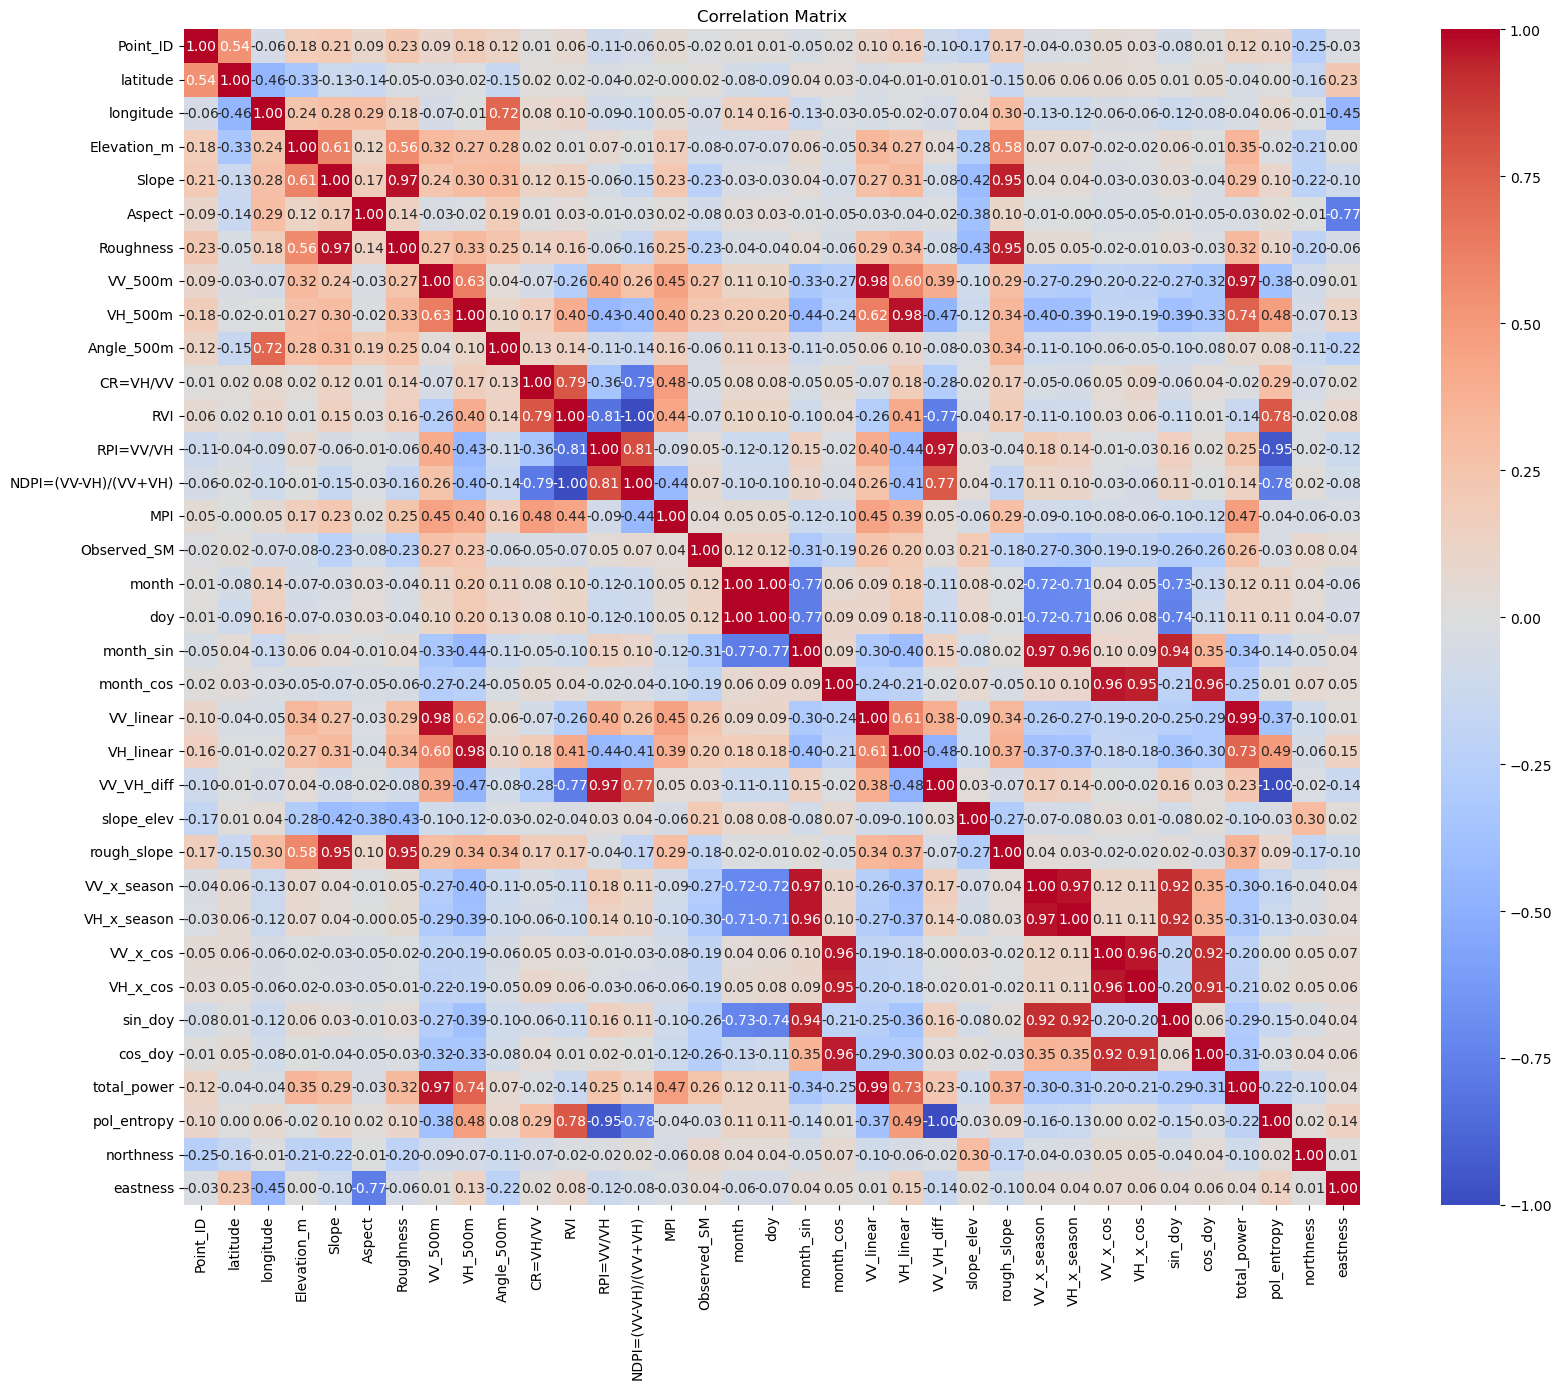

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 14))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
import pandas as pd
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# ─────────────────────────────────────────────
#  FEATURES
# ─────────────────────────────────────────────

FEATURES = [
    'doy',
    'VV_500m', 'VH_500m', 'Angle_500m',
    'VV_linear', 'VH_linear', 'VV_VH_diff',
    'CR=VH/VV', 'RVI', 'NDPI=(VV-VH)/(VV+VH)', 'MPI',
    'Elevation_m', 'Slope', 'Roughness',
    'slope_elev', 'rough_slope',
    'VV_x_season', 'VH_x_season', 'VV_x_cos', 'VH_x_cos',
    'sin_doy', 'cos_doy', 'pol_entropy', 'northness', 'eastness'
]

# ── EXTRA INTERACTION FEATURES ──────────────────────────────────────────────

df['VV_x_elev']      = df['VV_500m']    * df['Elevation_m']
df['RVI_x_slope']    = df['RVI']        * df['Slope']
df['CR_x_doy']       = df['CR=VH/VV']  * df['sin_doy']

df['VV_rolling_std']  = df.groupby('Point_ID')['VV_500m'].transform(
                            lambda x: x.rolling(3, min_periods=1).std()).fillna(0)
df['VH_rolling_mean'] = df.groupby('Point_ID')['VH_500m'].transform(
                            lambda x: x.rolling(3, min_periods=1).mean())

EXTRA = ['VV_x_elev', 'RVI_x_slope', 'CR_x_doy', 'VV_rolling_std', 'VH_rolling_mean']

ALL_FEATURES = FEATURES + EXTRA

X = df[imp_shapfeatures].copy()
y = df['Observed_SM'].copy()

# ─────────────────────────────────────────────
#  3-WAY SPATIAL SPLIT  (Train / Val / Test)
# ─────────────────────────────────────────────

all_points = df['Point_ID'].unique()
np.random.seed(42)
shuffled = np.random.permutation(all_points)

test_pts  = shuffled[:20]       # ~20% — final holdout, touched only at the end
val_pts   = shuffled[20:30]     # ~15% — monitor overfitting, tune weights
train_pts = shuffled[30:]       # ~65% — Optuna CV + model fitting

train_mask = df['Point_ID'].isin(train_pts)
val_mask   = df['Point_ID'].isin(val_pts)
test_mask  = df['Point_ID'].isin(test_pts)

X_train_df   = X[train_mask].reset_index(drop=True)
y_train_s    = y[train_mask].reset_index(drop=True)
groups_train = df.loc[train_mask, 'Point_ID'].reset_index(drop=True).values

X_val_df     = X[val_mask].reset_index(drop=True)
y_val_s      = y[val_mask].reset_index(drop=True)

X_test_df    = X[test_mask].reset_index(drop=True)
y_test_s     = y[test_mask].reset_index(drop=True)

# Scaler fit on train only
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train_df)
X_val_sc   = scaler.transform(X_val_df)
X_test_sc  = scaler.transform(X_test_df)

y_train = y_train_s.values
y_val   = y_val_s.values
y_test  = y_test_s.values

gkf = GroupKFold(n_splits=5)

print(f"Split summary:")
print(f"  Train : {len(train_pts)} points, {train_mask.sum()} rows")
print(f"  Val   : {len(val_pts)} points, {val_mask.sum()} rows")
print(f"  Test  : {len(test_pts)} points, {test_mask.sum()} rows")


# ─────────────────────────────────────────────
#  METRICS
# ─────────────────────────────────────────────

def full_metrics(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    r    = np.corrcoef(y_true, y_pred)[0, 1]
    print(f"\n{'─'*40}")
    print(f"  {label}")
    print(f"{'─'*40}")
    print(f"  R²   : {r2:.4f}")
    print(f"  R    : {r:.4f}")
    print(f"  RMSE : {rmse:.4f} m³/m³")
    print(f"  MAE  : {mae:.4f} m³/m³")
    print(f"  Bias : {bias:.4f} m³/m³")
    return dict(r2=r2, r=r, rmse=rmse, mae=mae, bias=bias)


# ─────────────────────────────────────────────
#  OPTUNA — XGBoost
# ─────────────────────────────────────────────

print("\nTuning XGBoost with Optuna...")

def xgb_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 200, 1000),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        learning_rate    = trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        subsample        = trial.suggest_float('subsample', 0.3, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        gamma            = trial.suggest_float('gamma', 0.0, 2.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 5.0),
        reg_lambda       = trial.suggest_float('reg_lambda', 0.5, 10.0),
        objective        = 'reg:squarederror',
        tree_method      = 'hist',
        random_state     = 42,
        n_jobs           = -1,
    )

    fold_scores = []
    for tr_idx, val_idx in gkf.split(X_train_df, y_train_s, groups_train):
        X_tr  = X_train_df.iloc[tr_idx].values
        X_v   = X_train_df.iloc[val_idx].values
        y_tr  = y_train_s.iloc[tr_idx].values
        y_v   = y_train_s.iloc[val_idx].values

        sc      = RobustScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_v_sc  = sc.transform(X_v)

        model = XGBRegressor(**params)
        model.fit(X_tr_sc, y_tr, verbose=False)
        fold_scores.append(r2_score(y_v, model.predict(X_v_sc)))

    return np.mean(fold_scores)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f"\nXGB best CV R² : {study.best_value:.4f}")
print(f"XGB best params: {study.best_params}")


# ─────────────────────────────────────────────
#  OPTUNA — ExtraTrees
# ─────────────────────────────────────────────

print("\nTuning ExtraTrees with Optuna...")

def et_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 15),
        max_features     = trial.suggest_float('max_features', 0.3, 1.0),
    )

    fold_scores = []
    for tr_idx, val_idx in gkf.split(X_train_df, y_train_s, groups_train):
        X_tr  = X_train_df.iloc[tr_idx].values
        X_v   = X_train_df.iloc[val_idx].values
        y_tr  = y_train_s.iloc[tr_idx].values
        y_v   = y_train_s.iloc[val_idx].values

        sc      = RobustScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_v_sc  = sc.transform(X_v)

        model = ExtraTreesRegressor(**params, random_state=42, n_jobs=-1)
        model.fit(X_tr_sc, y_tr)
        fold_scores.append(r2_score(y_v, model.predict(X_v_sc)))

    return np.mean(fold_scores)

study_et = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_et.optimize(et_objective, n_trials=100, show_progress_bar=True)

print(f"\nET  best CV R² : {study_et.best_value:.4f}")
print(f"ET  best params: {study_et.best_params}")


# ─────────────────────────────────────────────
#  TRAIN FINAL MODELS
# ─────────────────────────────────────────────

best_xgb_params = study.best_params.copy()
best_xgb_params.update(dict(
    objective    = 'reg:squarederror',
    tree_method  = 'hist',
    random_state = 42,
    n_jobs       = -1,
))

best_xgb = XGBRegressor(**best_xgb_params)
best_et  = ExtraTreesRegressor(**study_et.best_params, random_state=42, n_jobs=-1)

# XGBoost: pass val set as eval_set to monitor validation RMSE during training
best_xgb.fit(
    X_train_sc, y_train,
    eval_set=[(X_train_sc, y_train), (X_val_sc, y_val)],
    verbose=False        # change to 50 to print val-RMSE every 50 rounds
)

best_et.fit(X_train_sc, y_train)


# ─────────────────────────────────────────────
#  TUNE ENSEMBLE WEIGHTS  (on spatial val set)
# ─────────────────────────────────────────────

xgb_val_pred = best_xgb.predict(X_val_sc)
et_val_pred  = best_et.predict(X_val_sc)

best_r2, best_w = -999, 0.5
for w in np.arange(0.1, 0.95, 0.05):
    r2 = r2_score(y_val, w * xgb_val_pred + (1 - w) * et_val_pred)
    if r2 > best_r2:
        best_r2, best_w = r2, w

wx = round(best_w, 2)
we = round(1 - wx, 2)
print(f"\nBest ensemble weights — XGB: {wx}  ET: {we}")
print(f"Val  R² with best weights : {best_r2:.4f}")


# ─────────────────────────────────────────────
#  EVALUATE  (Train / Val / Test)
# ─────────────────────────────────────────────

train_pred = wx * best_xgb.predict(X_train_sc) + we * best_et.predict(X_train_sc)
val_pred   = wx * xgb_val_pred                 + we * et_val_pred
test_pred  = wx * best_xgb.predict(X_test_sc)  + we * best_et.predict(X_test_sc)

train_m = full_metrics(y_train, train_pred, "TRAIN")
val_m   = full_metrics(y_val,   val_pred,   "VALIDATION (spatial holdout)")
test_m  = full_metrics(y_test,  test_pred,  "TEST (spatial holdout)")


# ─────────────────────────────────────────────
#  5-FOLD SPATIAL CV  (training data only)
# ─────────────────────────────────────────────

print(f"\n{'─'*40}")
print(f"  5-FOLD SPATIAL CV (train split only)")
print(f"{'─'*40}")

fold_r2, fold_rmse, fold_mae = [], [], []

for fold, (tr_idx, v_idx) in enumerate(
        gkf.split(X_train_df, y_train_s, groups=groups_train), 1):

    X_tr  = X_train_df.iloc[tr_idx].values
    X_v   = X_train_df.iloc[v_idx].values
    y_tr  = y_train[tr_idx]
    y_v   = y_train[v_idx]

    sc      = RobustScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_v_sc  = sc.transform(X_v)

    m_xgb = XGBRegressor(**best_xgb_params)
    m_et  = ExtraTreesRegressor(**study_et.best_params, random_state=42, n_jobs=-1)

    m_xgb.fit(X_tr_sc, y_tr, verbose=False)
    m_et.fit(X_tr_sc, y_tr)

    v_pred = wx * m_xgb.predict(X_v_sc) + we * m_et.predict(X_v_sc)

    f_r2   = r2_score(y_v, v_pred)
    f_rmse = np.sqrt(mean_squared_error(y_v, v_pred))
    f_mae  = mean_absolute_error(y_v, v_pred)

    fold_r2.append(f_r2);  fold_rmse.append(f_rmse);  fold_mae.append(f_mae)

    print(f"  Fold {fold}  →  R²={f_r2:.4f}  RMSE={f_rmse:.4f}  MAE={f_mae:.4f}")

print(f"{'─'*40}")
print(f"  Mean  →  R²={np.mean(fold_r2):.4f}  RMSE={np.mean(fold_rmse):.4f}  MAE={np.mean(fold_mae):.4f}")
print(f"  Std   →  R²={np.std(fold_r2):.4f}  RMSE={np.std(fold_rmse):.4f}  MAE={np.std(fold_mae):.4f}")


# ─────────────────────────────────────────────
#  FEATURE IMPORTANCE
# ─────────────────────────────────────────────

xgb_imp = pd.Series(best_xgb.feature_importances_, index=imp_shapfeatures)
et_imp  = pd.Series(best_et.feature_importances_,  index=imp_shapfeatures)
avg_imp = (wx * xgb_imp + we * et_imp).sort_values(ascending=False)

print("\nTop 10 Feature Importances (weighted avg):")
print(avg_imp.head(10).round(4).to_string())

Split summary:
  Train : 70 points, 285 rows
  Val   : 10 points, 38 rows
  Test  : 20 points, 78 rows

Tuning XGBoost with Optuna...


  0%|          | 0/100 [00:00<?, ?it/s]


XGB best CV R² : 0.3368
XGB best params: {'n_estimators': 691, 'max_depth': 5, 'learning_rate': 0.009273480169398735, 'subsample': 0.8045510255236175, 'colsample_bytree': 0.8254602849044538, 'min_child_weight': 10, 'gamma': 0.005511411054207876, 'reg_alpha': 0.11901066029139774, 'reg_lambda': 4.46924417190485}

Tuning ExtraTrees with Optuna...


  0%|          | 0/100 [00:00<?, ?it/s]


ET  best CV R² : 0.3771
ET  best params: {'n_estimators': 570, 'max_depth': 10, 'min_samples_leaf': 4, 'max_features': 0.6774492379796008}

Best ensemble weights — XGB: 0.1  ET: 0.9
Val  R² with best weights : 0.5643

────────────────────────────────────────
  TRAIN
────────────────────────────────────────
  R²   : 0.7030
  R    : 0.8574
  RMSE : 0.0440 m³/m³
  MAE  : 0.0347 m³/m³
  Bias : -0.0000 m³/m³

────────────────────────────────────────
  VALIDATION (spatial holdout)
────────────────────────────────────────
  R²   : 0.5643
  R    : 0.7676
  RMSE : 0.0539 m³/m³
  MAE  : 0.0436 m³/m³
  Bias : 0.0087 m³/m³

────────────────────────────────────────
  TEST (spatial holdout)
────────────────────────────────────────
  R²   : 0.4741
  R    : 0.6993
  RMSE : 0.0616 m³/m³
  MAE  : 0.0487 m³/m³
  Bias : -0.0024 m³/m³

────────────────────────────────────────
  5-FOLD SPATIAL CV (train split only)
────────────────────────────────────────
  Fold 1  →  R²=0.2354  RMSE=0.0683  MAE=0.0556
  F

Computing SHAP for XGBoost...
Computing SHAP for ExtraTrees...


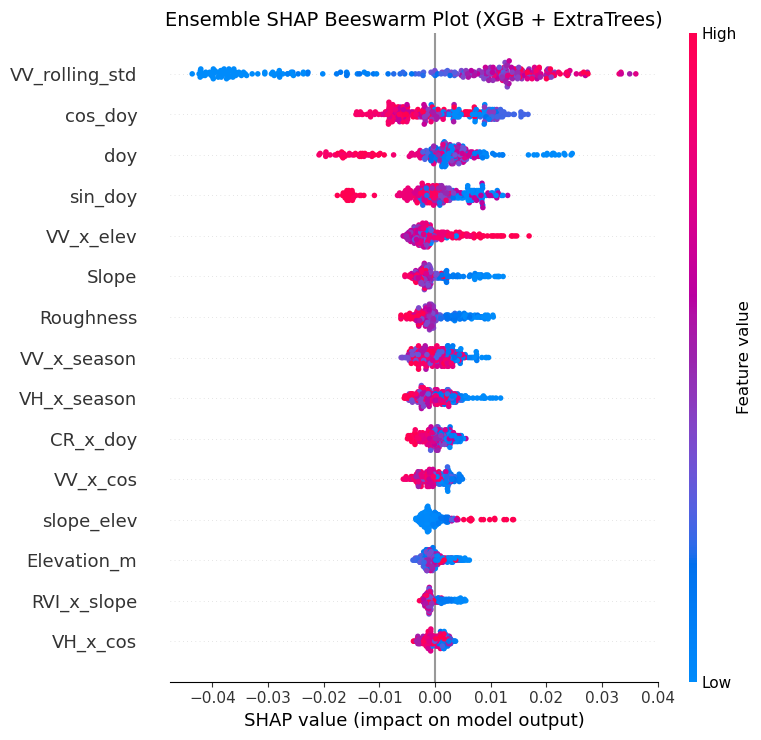

In [6]:
import shap
import numpy as np
import matplotlib.pyplot as plt


# STEP 1 — SHAP FOR XGBOOST

print("Computing SHAP for XGBoost...")

explainer_xgb = shap.TreeExplainer(best_xgb)
shap_xgb = explainer_xgb.shap_values(X_train_sc)


# STEP 2 — SHAP FOR EXTRA TREES
print("Computing SHAP for ExtraTrees...")

explainer_et = shap.TreeExplainer(best_et)
shap_et = explainer_et.shap_values(X_train_sc)


# STEP 3 — ENSEMBLE SHAP (WEIGHTED)

ensemble_shap = (
    wx * shap_xgb +
    we * shap_et
)

# Convert to mean absolute importance
shap_importance = np.abs(ensemble_shap).mean(axis=0)

# Create ranked series
shap_importance = shap_importance / shap_importance.sum()


# STEP 4 — PROFESSIONAL PLOT (CLEAN BARH)

import pandas as pd

imp_series = pd.Series(shap_importance, index=ALL_FEATURES)
imp_series = imp_series.sort_values(ascending=True)

plt.figure(figsize=(10, 7))

shap.summary_plot(
    ensemble_shap,
    X_train_sc,
    feature_names=ALL_FEATURES,
    max_display=15,
    show=False
)

plt.title("Ensemble SHAP Beeswarm Plot (XGB + ExtraTrees)", fontsize=14)

plt.tight_layout()
plt.show()

In [9]:
imp_shapfeatures= imp_series.sort_values(ascending=False).head(15).index.tolist()